## 우리금융 실습 2주차

In [1]:
# !pip install cvxpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso,Ridge,ElasticNet
from sklearn.linear_model import LassoCV,RidgeCV,ElasticNetCV
from sklearn.metrics import mean_squared_error

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
diabetes=load_diabetes()
data = diabetes.data # 당뇨의 진행도
features = diabetes.target
col_name=diabetes["feature_names"]
print(col_name)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, features, test_size=0.3, random_state=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 1. Ridge and Lasso
- Elasticnet을 Ridge로 사용하기

In [6]:
ridge_el = ElasticNet(alpha=1.0, l1_ratio=0, max_iter=10000, random_state=1)
ridge_el.fit(X_train, y_train)

y_pred = ridge_el.predict(X_test)
mse_el = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (Ridge): {mse_el:.4f}")
df=pd.DataFrame([ridge_el.coef_],columns=col_name)
print(f"Coefficients (Ridge):")
print(df)

Mean Squared Error (Ridge): 2973.6102
Coefficients (Ridge):
        age       sex        bmi        bp        s1        s2        s3  \
0  1.619435 -4.171459  16.236727  9.900725  0.281711 -1.712183 -7.427104   

         s4         s5        s6  
0  5.837292  12.527865  5.243472  


In [7]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Mean Squared Error (Ridge): {mse_ridge:.4f}")
df=pd.DataFrame([ridge_model.coef_],columns=col_name)
print(f"Coefficients (Ridge):")
print(df)

Mean Squared Error (Ridge): 2833.6238
Coefficients (Ridge):
        age        sex        bmi         bp         s1        s2        s3  \
0 -0.594851 -11.220934  28.163708  15.796934 -22.993568  9.788597  0.497228   

         s4         s5        s6  
0  9.236103  29.252631  2.350265  


- 결과 다르다. Ridge()와 ElasticNet()의 목적함수가 다르기 때문
$$\mathrm{Elastic Net : } \frac{1}{n} (Y-X\beta)_2^2 + 0.5 \cdot \alpha \cdot ||\beta||_2^2$$

$$\mathrm{Ridge : } (Y-X\beta)_2^2 + \alpha \cdot ||\beta||_2^2$$

In [8]:
n_train = X_train.shape[0]
ridge_el = ElasticNet(alpha=1.0 / n_train, l1_ratio=0, max_iter=10000, random_state=1)
ridge_el.fit(X_train, y_train)

y_pred = ridge_el.predict(X_test)
mse_el = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (Ridge): {mse_el:.4f}")
df=pd.DataFrame([ridge_el.coef_],columns=col_name)
print(f"Coefficients (Ridge):")
print(df)

Mean Squared Error (Ridge): 2833.6238
Coefficients (Ridge):
        age        sex        bmi         bp         s1        s2        s3  \
0 -0.594851 -11.220934  28.163708  15.796934 -22.993568  9.788597  0.497228   

         s4         s5        s6  
0  9.236103  29.252631  2.350265  


In [9]:
alphas = np.logspace(-3,30, 100)

ridge_el_cv=ElasticNetCV(alphas = alphas, l1_ratio=0, max_iter=10000, cv=5, random_state=1)
ridge_el_cv.fit(X_train,y_train)

y_pred_cv = ridge_el_cv.predict(X_test)
mse_el_cv = mean_squared_error(y_test, y_pred_cv)

print(f"Mean Squared Error (Ridge): {mse_el_cv:.4f}")
print(f"Best lambda (Ridge): {ridge_el_cv.alpha_:.4f}")

Mean Squared Error (Ridge): 2835.4595
Best lambda (Ridge): 0.1000


In [10]:
ridge_cv=RidgeCV(alphas = alphas, cv=5)
ridge_cv.fit(X_train,y_train)

y_pred_ridge_cv = ridge_cv.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_ridge_cv)

print(f"Mean Squared Error (Ridge): {mse_cv:.4f}")
print(f"Best lambda (Ridge): {ridge_cv.alpha_:.4f}")

Mean Squared Error (Ridge): 2839.3215
Best lambda (Ridge): 21.5443


- Elasticnet을 Lasso로 사용하기

In [11]:
lasso_el = ElasticNet(alpha=1.0, l1_ratio=1, max_iter=10000, random_state=1)
# l1_ratio =1인 경우 lasso regression과 같은 역할
lasso_el.fit(X_train, y_train)

y_pred = lasso_el.predict(X_test)
mse_el = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (Lasso): {mse_el:.4f}")
df=pd.DataFrame([lasso_el.coef_],columns=col_name)
print(f"Coefficients (Lasso):")
print(df)

Mean Squared Error (Lasso): 2852.7621
Coefficients (Lasso):
   age      sex        bmi         bp       s1   s2        s3        s4  \
0 -0.0 -9.20788  28.309676  14.418934 -5.25633 -0.0 -8.752374  1.613008   

          s5        s6  
0  23.723197  1.665895  


In [12]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Mean Squared Error (Lasso): {mse_lasso:.4f}")
df=pd.DataFrame([lasso_model.coef_],columns=col_name)
print(f"Coefficients (Lasso):")
print(df)

Mean Squared Error (Lasso): 2852.7621
Coefficients (Lasso):
   age      sex        bmi         bp       s1   s2        s3        s4  \
0 -0.0 -9.20788  28.309676  14.418934 -5.25633 -0.0 -8.752374  1.613008   

          s5        s6  
0  23.723197  1.665895  


- Lasso()와 ElasticNet()의 목적함수가 같기 때문에 결과가 같음.

In [13]:
alphas = np.logspace(-3,30, 100)

lasso_el_cv=ElasticNetCV(alphas = alphas, l1_ratio=1, max_iter=10000, cv=5, random_state=1)
lasso_el_cv.fit(X_train,y_train)

y_pred_cv = lasso_el_cv.predict(X_test)
mse_el_cv = mean_squared_error(y_test, y_pred_cv)

print(f"Mean Squared Error (Lasso): {mse_el_cv:.4f}")
print(f"Best lambda (Lasso): {lasso_el_cv.alpha_:.4f}")

Mean Squared Error (Lasso): 2852.7621
Best lambda (Lasso): 1.0000


In [14]:
lasso_cv=LassoCV(alphas = alphas, cv=5)
lasso_cv.fit(X_train,y_train)

y_pred_lasso_cv = lasso_cv.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_lasso_cv)

print(f"Mean Squared Error (Lasso): {mse_cv:.4f}")
print(f"Best lambda (Lasso): {lasso_cv.alpha_:.4f}")

Mean Squared Error (Lasso): 2852.7621
Best lambda (Lasso): 1.0000


#### Elastic Net 실습하기

In [15]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=0)
elastic_net.fit(X_train, y_train)

y_pred = elastic_net.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (ElasticNet): {mse:.4f}")
df=pd.DataFrame([elastic_net.coef_],columns=col_name)
print(f"Coefficients (ElasticNet):")
print(df)

Mean Squared Error (ElasticNet): 2842.1394
Coefficients (ElasticNet):
        age        sex        bmi         bp        s1        s2        s3  \
0 -0.229383 -10.412596  27.292177  15.110094 -5.051449 -3.229709 -7.352467   

         s4         s5        s6  
0  6.568375  21.766212  2.985475  


In [16]:
elastic_cv=ElasticNetCV(cv=5, random_state=0)
elastic_cv.fit(X_train,y_train)

y_pred_cv = elastic_cv.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)

print(f"Mean Squared Error (ElasticNet): {mse_cv:.4f}")
print(f"Best alpha (ElasticNet): {lasso_el_cv.alpha_:.4f}")
print(f"Best L1 ratio (ElasticNet): {lasso_el_cv.l1_ratio:.4f}")


Mean Squared Error (ElasticNet): 2836.6706
Best alpha (ElasticNet): 1.0000
Best L1 ratio (ElasticNet): 1.0000


#### Fused Lasso for image denoising

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from skimage import data, color, util


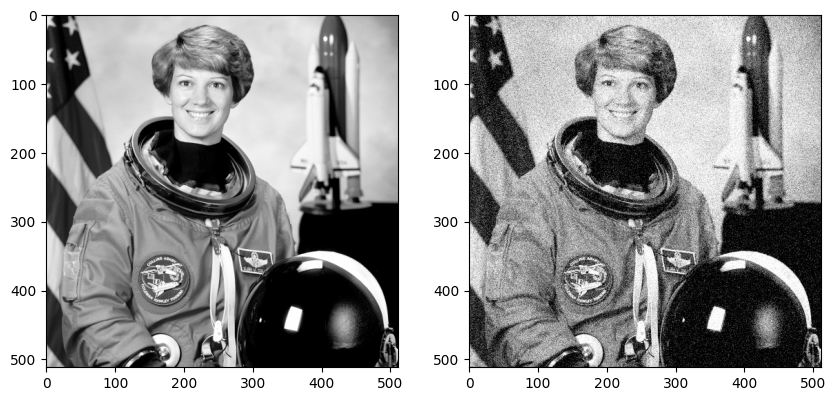

In [18]:
# 1. 이미지 로드 및 노이즈 추가
original_image = color.rgb2gray(data.astronaut())
noisy_image = original_image + np.random.normal(loc=0, scale=0.1, size=original_image.shape)
noisy_image = np.clip(noisy_image, 0, 1)  # 값 범위 유지

fig, axis = plt.subplots(ncols=2, figsize=(10, 8))
axis[0].imshow(original_image, cmap=plt.cm.Greys_r)
axis[1].imshow(noisy_image, cmap=plt.cm.Greys_r)


In [19]:
# 2. 이미지 벡터 변환
m, n = noisy_image.shape
y = noisy_image.flatten()

In [ ]:
# 3. Fused Lasso 최적화 문제 설정
beta = cp.Variable(m * n)
lambda2 = 0.1  # Fused Lasso 강도

diff_x = beta[:-1] - beta[1:] # 가로방향 차이
diff_y = beta[:-n] - beta[n:] # 세로방향 차이

 ## cvxpy로 목적함수 최적화-> 강력한 대신 오래 걸린다.주의! 다른 최적화 방법 사용 가능
objective = cp.Minimize(cp.sum_squares(y - beta) + lambda2 * (cp.norm1(diff_x) + cp.norm1(diff_y)))

problem = cp.Problem(objective)
problem.solve()

![image.png](attachment:a1c9317d-1f8c-4ba7-baf6-08bbb575259b.png)

In [ ]:
# 4. 결과 출력
restored_image = beta.value.reshape(m, n)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(original_image, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Noisy Image")
plt.imshow(noisy_image, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Denoised Image (Fused Lasso)")
plt.imshow(restored_image, cmap='gray')
plt.axis("off")

plt.show()

#### 직접 해보기: Boston data

In [ ]:
import urllib.request

boston_df=pd.read_csv("housing.csv")
boston_df.head()

In [ ]:
## 1. 각 변수의 기초통계량을 살펴본다
boston_df.describe()

In [ ]:
## 2. Training set과 Test set으로 분할하고 설명변수들을 표준화한다.
X= boston_df.drop(columns=['MEDV'])
y= boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## 3. Ridge, Lasso, Elastic Net을 적용한다.
# Ridge
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100))
ridge_cv.fit(X_train_scaled, y_train)
ridge_pred = ridge_cv.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_alpha = ridge_cv.alpha_

#Lasso
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5)
lasso_cv.fit(X_train_scaled, y_train)
lasso_pred = lasso_cv.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_alpha = lasso_cv.alpha_

#Elastic Net
elastic_net_cv = ElasticNetCV(alphas=np.logspace(-3, 3, 100), l1_ratio=np.linspace(0.1, 0.9, 9), cv=5)
elastic_net_cv.fit(X_train_scaled, y_train)
elastic_net_pred = elastic_net_cv.predict(X_test_scaled)
elastic_net_mse = mean_squared_error(y_test, elastic_net_pred)
elastic_net_alpha = elastic_net_cv.alpha_
elastic_net_l1_ratio = elastic_net_cv.l1_ratio_

In [ ]:
## 4. 각 모형을 평가하여 어떤 모형이 가장 좋은지 판단한다.
print(f"Ridge MSE: {ridge_mse}, Alpha: {ridge_alpha}")
print(f"Lasso MSE: {lasso_mse}, Alpha: {lasso_alpha}")
print(f"Elastic Net MSE: {elastic_net_mse}, Alpha: {elastic_net_alpha}, L1 Ratio: {elastic_net_l1_ratio}")

In [ ]:
## 5. Lasso와 Elastic Net을 통해 선택된 변수들은 무엇인가?
selected_features_lasso = X.columns[np.abs(lasso_cv.coef_) > 0]
selected_features_elastic = X.columns[np.abs(elastic_net_cv.coef_) > 0]
print(f"Selected features (Lasso): {list(selected_features_lasso)}")
print(f"Selected features (Elastic Net): {list(selected_features_elastic)}")

### 2. 의사결정나무

In [ ]:
!pip install ISLP

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from ISLP import load_data
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [ ]:
# Hitters Data_load
hitters = load_data('Hitters')

# Remove_NA
hitters = hitters.dropna()

X = hitters[['Years', 'Hits']]
y = hitters['Salary']

print(hitters.info())

In [ ]:
# Scatterplot
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(data=hitters, x='Years', y='Hits', hue='Salary', palette='terrain', edgecolor='k')
plt.title('Years vs Hits with Salary Color Gradient')
plt.xlabel('Years')
plt.ylabel('Hits')
plt.legend(title='Salary', loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

In [ ]:
# Fit Tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X, y)

# Tree plot
plt.figure(figsize=(10, 6))

plot_tree(tree,
          max_depth=2, # For simple Plot
          feature_names=['Years', 'Hits'],
          filled=True,
          rounded=True,
          impurity=False,
          proportion=False)

plt.title("An Introduction to Decision Tree")
plt.show()

In [ ]:
# Data_load
german = fetch_openml(name="credit-g", version=1, as_frame=True)['data']
y= fetch_openml(name="credit-g", version=1, as_frame=True)['target']

# Data_Summary
print(german.info())

In [ ]:
print(y.head())

- Full Tree

In [ ]:
# One-Hot Encoding (Label encoding in this case)
label_encoder = LabelEncoder()
X_encoded = german.apply(label_encoder.fit_transform)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Fit Decision Tree classifier on training data
tree_german = DecisionTreeClassifier(random_state=42)
tree_german.fit(X_train, y_train)

# Predict on test data
y_pred = tree_german.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", accuracy)

# Plot the decision tree (limited to depth=2 for visualization)
plt.figure(figsize=(12, 8))
plot_tree(tree_german,
          max_depth=2,
          filled=True,
          rounded=True,
          feature_names=german.columns,
          class_names=np.unique(y).astype(str),
          impurity=False,
          proportion=False)
plt.title("Decision Tree for German Credit Data")
plt.show()

#### Pruning

In [ ]:
# Fit tree without pruning using training data
tree_german = DecisionTreeClassifier(random_state=42)
tree_german.fit(X_train, y_train)

# Cost Complexity Pruning using training data
path = tree_german.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities  # Store alpha values and total impurities

# Generate pruned trees for each ccp_alpha and evaluate on test data
trees = []
test_accuracies = []
for ccp_alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    pruned_tree.fit(X_train, y_train)
    trees.append(pruned_tree)
    y_pred = pruned_tree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)

# Calculate quantile summary of test accuracies
accuracy_series = pd.Series(test_accuracies)
quantile_summary = accuracy_series.describe(percentiles=[0.25, 0.5, 0.75])
print("Quantile Summary of Test Accuracy:")
print(quantile_summary)

# Find the ccp_alpha with the smallest test accuracy
min_accuracy_index = np.argmin(test_accuracies)
min_accuracy_ccp_alpha = ccp_alphas[min_accuracy_index]
min_accuracy_value = test_accuracies[min_accuracy_index]

# Print best ccp_alpha and its corresponding test accuracy, formatted to 4 decimal places
print("Best ccp_alpha: {:.5f}".format(min_accuracy_ccp_alpha))
print("Test Accuracy: {:.4f}".format(min_accuracy_value))

# Compare tree depths for each pruned tree and visualize the relationship with ccp_alpha
depths = [t.get_depth() for t in trees]

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, depths, marker="o", linestyle="--", color="b")
plt.xlabel("Alpha")
plt.ylabel("Depths of Tree")
plt.title("Tree Depth According to Alpha")
plt.show()


In [ ]:
# Alpha
optimal_alpha = 0.005 # max(ccp_alphas) = 0.04

# Fit tree with Alpha
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_alpha)
pruned_tree.fit(X_train, y_train)

# Comparison of original Tree and pruning Tree

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

axes[0].set_title("Original Decision Tree")
plot_tree(tree_german,
          filled=True,
          rounded=True,
          feature_names=german.columns,
          class_names=y.unique().astype(str),
          impurity=False,
          proportion=False,
          ax=axes[0])

axes[1].set_title("Pruned Decision Tree")
plot_tree(pruned_tree,
          filled=True,
          rounded=True,
          feature_names=german.columns,
          class_names=y.unique().astype(str),
          impurity=False,
          proportion=False,
          ax=axes[1])

plt.tight_layout()
plt.show()

#### Find Best alpha through CV

In [ ]:
# 10-fold CV setting
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=1)

# CCP alpha value range setting
cp_values = np.linspace(0.0001, 0.015, 40)

# Lists to store mean accuracy and mean terminal nodes for each ccp_alpha
mean_accuracies = []
mean_terminal_nodes = []

# Loop over each ccp_alpha value
for cp in cp_values:
    fold_accuracies = []
    fold_terminal_nodes = []

    # Perform 10-fold CV
    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Train Decision Tree with given ccp_alpha
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=cp)
        clf.fit(X_train_fold, y_train_fold)

        # Predict on validation fold and calculate accuracy
        y_pred = clf.predict(X_val_fold)
        acc = accuracy_score(y_val_fold, y_pred)
        fold_accuracies.append(acc)

        # Get the number of terminal nodes (leaves)
        fold_terminal_nodes.append(clf.get_n_leaves())

    # Calculate the mean accuracy and mean terminal nodes for current ccp_alpha
    mean_accuracies.append(np.mean(fold_accuracies))
    mean_terminal_nodes.append(np.mean(fold_terminal_nodes))

# Determine the best ccp_alpha based on highest mean accuracy
best_index = np.argmax(mean_accuracies)
best_cp = cp_values[best_index]
best_mean_accuracy = mean_accuracies[best_index]

# Print best ccp_alpha and its corresponding mean accuracy
print("Best ccp_alpha (from CV): {:.5f}".format(best_cp))
print("Mean Test Accuracy (CV) for best ccp_alpha: {:.4f}".format(best_mean_accuracy))

# Print quantile summary for mean accuracies and mean terminal nodes across cp values
mean_acc_series = pd.Series(mean_accuracies)
mean_term_series = pd.Series(mean_terminal_nodes)

print("\nQuantile Summary for Mean Accuracy across cp values:")
print(mean_acc_series.describe(percentiles=[0.25, 0.5, 0.75]))

print("\nQuantile Summary for Mean Terminal Nodes across cp values:")
print(mean_term_series.describe(percentiles=[0.25, 0.5, 0.75]))


#### 직접 해보기

In [ ]:
tips = sns.load_dataset("tips")
print(tips.head)

In [ ]:
# One-Hot Encoding
label_encoder = LabelEncoder()
X_tips = tips.drop(columns=["tip"]).apply(label_encoder.fit_transform)
y_tips = tips["tip"]

X_train, X_test, y_train, y_test = train_test_split(X_tips, y_tips, test_size=0.2, random_state=123)

# Fit Tree
tree_tips = DecisionTreeRegressor(random_state=42)
tree_tips.fit(X_train, y_train)

In [ ]:
# Predict on test data and calculate Mean Squared Error (MSE)
y_pred = tree_tips.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

# Plot the decision tree with max_depth=3 for visualization
plt.figure(figsize=(12, 8))
plot_tree(tree_tips,
          max_depth=3,
          filled=True,
          rounded=True,
          feature_names=X_tips.columns)
plt.title("Decision Tree for Tips Data (max_depth=3)")
plt.show()


### 3.Ensemble Methods

#### Boostrapping

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, fetch_openml, load_diabetes
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb

In [ ]:
# Data Load
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Set the number of Bootstrapping
B = 1000
n = len(df)
theta = []


# Execute bootstrapping
for i in range(B):
    # Resampling with replacement
    b = np.random.choice(n, size=n, replace=True)
    df_boot = df.iloc[b]

    X_boot = df_boot[['MedInc']]
    y_boot = df_boot['MedHouseVal']

    # Train model
    model = LinearRegression()
    model.fit(X_boot, y_boot)

    # Add beta0 * beta1
    intercept = model.intercept_
    slope = model.coef_
    theta.append(intercept * slope)

# quantile 0.05 and 0.95
sorted_theta = sorted(theta)
percentile_5 = np.percentile(sorted_theta, 5)
percentile_95 = np.percentile(sorted_theta, 95)

#print(sorted_theta)
print(f"percentile_5: {percentile_5}")
print(f"percentile_95: {percentile_95}")

# Draw histogram
plt.hist(theta, histtype='barstacked',
         edgecolor='black') # 색깔이 좀 이상...
plt.xlabel('beta0 * beta1')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.grid(True)
plt.show()

#### Bagging with multiple linear regression

In [ ]:
# Data_load
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Data_Split
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit linear regression through Bagging
def bagging_lm(X, y, B=100):
    n = len(X)
    coef_list = []
    fit_list = []
    for i in range(B):
        # Boostrap Sampling
        indices = np.random.choice(n, size=n, replace=True)
        X_boot = X.iloc[indices]
        y_boot = y.iloc[indices]

        # Fit model
        model = LinearRegression()
        model.fit(X_boot, y_boot)
        fit_list.append(model)
        coef_list.append(model.coef_)
    return fit_list, np.mean(coef_list, axis=0)

# Prediction
def predict_bagging_lm(models, new_X):
    predictions = np.array([model.predict(new_X) for model in models])
    return np.mean(predictions, axis=0)

# Fit Bagging model and Original model
np.random.seed(1)
bagging_models, bagging_coeffs = bagging_lm(X_train, y_train, B=1000)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Prediction
bag_pred = predict_bagging_lm(bagging_models, X_test)
lm_pred = linear_model.predict(X_test)

# Comparison
mse_bagging = mean_squared_error(y_test, bag_pred)
mse_linear = mean_squared_error(y_test, lm_pred)
print(f"MSE of Bagging: {mse_bagging}")
print(f"MSE of Original: {mse_linear}")

#### Random Forest

In [ ]:
# Data_load
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Data_Split
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

# Fit Random forest
rf1 = RandomForestRegressor(random_state=1)
rf1.fit(X_train, y_train)

# Prediction
RF_pred = rf1.predict(X_test)

# MSE
mse_rf = mean_squared_error(y_test, RF_pred)
print(f"MSE of RandomForest: {mse_rf}")

In [ ]:
# Feature_importances
importance = rf1.feature_importances_
feature_names = X.columns
importance_dict = dict(zip(feature_names, importance))

sorted_importance = sorted(importance_dict.items(), key=lambda item: item[1], reverse=True)

print("\nFeature_importances:")
for feature, imp in sorted_importance:
    print(f"{feature}: {imp}")

In [ ]:
'''Importance Score'''

sorted_importance = sorted(importance_dict.items(), key=lambda item: item[1], reverse=True)
features = [item[0] for item in sorted_importance]
importance_scores = [item[1] for item in sorted_importance]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features, importance_scores, color='skyblue')
plt.title('Feature_importances')

for i, v in enumerate(importance_scores):
    plt.text(v + 0.005, i, f'{v:.2f}', color='black', va='center') # 중요도 점수 포맷팅

plt.tight_layout()
plt.show()

#### Adaboost

In [ ]:
# Load data
german = fetch_openml("credit-g", version=1, as_frame=True)
german_df = german['data']
german_y= german.target

# Encode categorical data (convert strings to numbers)
label_encoder = LabelEncoder()
X_encoded = german_df.apply(label_encoder.fit_transform)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, german_y, test_size=0.2, random_state=42, stratify=german_y
)

In [ ]:
# Adaboost model
ada_model = AdaBoostClassifier(random_state=1)

# Train the AdaBoost model
ada_model.fit(X_train, y_train)


# Make predictions
y_pred = ada_model.predict(X_test)

# Evaluate the model
print("\n----- Model Evaluation -----")
print("\nAccuracy:", ada_model.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=german.target_names,
            yticklabels=german.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for AdaBoost')
plt.tight_layout()
plt.show()

In [ ]:
# Perform cross-validation
cv_scores = cross_val_score(ada_model, X_encoded, german_y, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

#### XGboost

In [ ]:
# Load German credit data
german = fetch_openml("credit-g", version=1, as_frame=True)
german_df = german['data']
german_y = german.target

# Encode categorical data (convert strings to numbers)
label_encoder = LabelEncoder()
X_encoded = german_df.apply(label_encoder.fit_transform)
y_encoded = label_encoder.fit_transform(german_y)

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(max_depth=2, learning_rate=1, objective='binary:logistic')

# Train the model on training data
xgb_model.fit(X_train, y_train)

# Predictions on training and test sets
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Calculate and print accuracies
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

In [ ]:
# Feature importance
feature_importance = xgb_model.feature_importances_
feature_names = german_df.columns.tolist()

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [(feature_names[i], feature_importance[i]) for i in sorted_idx]

print("\nFeature Importance:")
for feature, importance in sorted_features[:10]:  # Top 10 features
    print(f"{feature}: {importance:.4f}")

# Plot feature importance
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('Top 10 Feature Importance for XGboost')
plt.tight_layout()
plt.show()

#### 한번 해보기

In [ ]:
from sklearn.datasets import load_diabetes

# Load the diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

In [ ]:
# Load the diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Bootstrapping parameters
B = 1000  # number of bootstrap iterations
n = len(X)
feature_names = diabetes.feature_names

# DataFrame to store coefficients from each bootstrap iteration
coefficients = pd.DataFrame(columns=feature_names)

# Bootstrap and Lasso regression with random alpha values
for i in range(B):
    # Sample indices with replacement
    indices = np.random.choice(n, size=n, replace=True)
    X_boot = X.iloc[indices]
    y_boot = y[indices]

    # Fit Lasso model using alpha value
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_boot, y_boot)

    # Store coefficients from the current iteration
    coefficients.loc[i] = lasso.coef_

# Calculate the proportion of times each coefficient is zero
zero_proportions = (coefficients == 0).mean()

print("Proportion of zero coefficients for each feature:")
print(zero_proportions)

# Plot the results
plt.figure(figsize=(8, 5))
zero_proportions.sort_values().plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel('Proportion of zero coefficients')
plt.title('Bootstrap Lasso Zero Coefficients Proportions')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
